# What is a Flowsheet? (Intermediate)

**Prerequisites:** [00a_what_is_a_flowsheet_basic](./00a_what_is_a_flowsheet_basic.ipynb)

**Learning Objectives:**
- Understand flowsheets as systems of equations
- See how streams act as shared variables between units
- Learn about degrees of freedom analysis
- Connect the equation view to simulation

---

## From Pictures to Equations

In the basic tutorial, we saw flowsheets as pictures with boxes and arrows. Now we'll see them as **systems of equations**.

Every flowsheet simulation is really just solving equations. The question is: *what equations?*

## The Mass Balance Equation

The fundamental equation of chemical engineering is the **mass balance**:

$$\text{Accumulation} = \text{In} - \text{Out} + \text{Generation} - \text{Consumption}$$

For **steady-state** operation (no accumulation):

$$0 = \text{In} - \text{Out} + \text{Generation} - \text{Consumption}$$

Or rearranged:

$$\text{Out} = \text{In} + \text{Net Generation}$$

This applies to:
- **Total mass**: Mass in = Mass out (for non-reactive systems)
- **Each species**: Moles of species $i$ in = Moles out + moles reacted
- **Energy**: Energy in = Energy out + heat added/removed

## Example: A Simple Mixer

Let's start with the simplest multi-stream unit: a **mixer** that combines two streams.

```
    Stream 1 ──────►┐
                    ├───► Stream 3 (mixed)
    Stream 2 ──────►┘
```

**What equations describe this mixer?**

For each species $i$:
$$F_{3,i} = F_{1,i} + F_{2,i}$$

For temperature (assuming ideal mixing with constant heat capacity):
$$F_3 \cdot T_3 = F_1 \cdot T_1 + F_2 \cdot T_2$$

where $F_j = \sum_i F_{j,i}$ is the total molar flow of stream $j$.

Let's implement this mathematically.

In [1]:
# Setup
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)

from difflow import make_stream, get_flows, combine_streams, total_flow

In [2]:
# Define the mixer equations explicitly

def mixer_equations(stream1, stream2):
    """
    Solve the mixer equations:
        F3_i = F1_i + F2_i  (for each species)
        T3 = (F1*T1 + F2*T2) / F3  (energy balance, assuming same Cp)
        P3 = min(P1, P2)  (take lower pressure)
    """
    # Mass balances - one equation per species
    flows1 = get_flows(stream1)
    flows2 = get_flows(stream2)
    
    mixed_flows = {}
    for species in flows1:
        # This IS the equation: F3_i = F1_i + F2_i
        mixed_flows[species] = flows1[species] + flows2[species]
    
    # Energy balance - simplified (assumes same Cp for all)
    F1_total = sum(flows1.values())
    F2_total = sum(flows2.values())
    F3_total = F1_total + F2_total
    
    # T3 from: F1*Cp*T1 + F2*Cp*T2 = F3*Cp*T3
    # Canceling Cp: T3 = (F1*T1 + F2*T2) / F3
    T3 = (F1_total * stream1['T'] + F2_total * stream2['T']) / F3_total
    
    # Pressure - take minimum (can't increase by mixing)
    P3 = jnp.minimum(stream1['P'], stream2['P'])
    
    return make_stream(mixed_flows, T=T3, P=P3)


# Create two inlet streams
stream1 = make_stream({'A': 10.0, 'B': 5.0}, T=300.0, P=200000.0)
stream2 = make_stream({'A': 5.0, 'B': 15.0}, T=350.0, P=180000.0)

# Solve the mixer equations
stream3 = mixer_equations(stream1, stream2)

print("Mixer Example")
print("=" * 50)
print("\nStream 1 (inlet):")
print(f"  F_A = {float(get_flows(stream1)['A']):.1f} mol/s")
print(f"  F_B = {float(get_flows(stream1)['B']):.1f} mol/s")
print(f"  T = {float(stream1['T']):.1f} K")

print("\nStream 2 (inlet):")
print(f"  F_A = {float(get_flows(stream2)['A']):.1f} mol/s")
print(f"  F_B = {float(get_flows(stream2)['B']):.1f} mol/s")
print(f"  T = {float(stream2['T']):.1f} K")

print("\nStream 3 (outlet - computed from equations):")
print(f"  F_A = {float(get_flows(stream3)['A']):.1f} mol/s  (= 10 + 5)")
print(f"  F_B = {float(get_flows(stream3)['B']):.1f} mol/s  (= 5 + 15)")
print(f"  T = {float(stream3['T']):.1f} K  (flow-weighted average)")

Mixer Example

Stream 1 (inlet):
  F_A = 10.0 mol/s
  F_B = 5.0 mol/s
  T = 300.0 K

Stream 2 (inlet):
  F_A = 5.0 mol/s
  F_B = 15.0 mol/s
  T = 350.0 K

Stream 3 (outlet - computed from equations):
  F_A = 15.0 mol/s  (= 10 + 5)
  F_B = 20.0 mol/s  (= 5 + 15)
  T = 328.6 K  (flow-weighted average)


## Counting Equations and Variables

Let's count what we have in the mixer:

**Variables:**
- Stream 1: $F_{1,A}$, $F_{1,B}$, $T_1$, $P_1$ → 4 variables
- Stream 2: $F_{2,A}$, $F_{2,B}$, $T_2$, $P_2$ → 4 variables
- Stream 3: $F_{3,A}$, $F_{3,B}$, $T_3$, $P_3$ → 4 variables
- **Total: 12 variables**

**Equations from the mixer:**
- Mass balance for A: $F_{3,A} = F_{1,A} + F_{2,A}$
- Mass balance for B: $F_{3,B} = F_{1,B} + F_{2,B}$
- Energy balance: $F_3 T_3 = F_1 T_1 + F_2 T_2$
- Pressure: $P_3 = \min(P_1, P_2)$
- **Total: 4 equations**

**Degrees of freedom: 12 - 4 = 8**

This means we need to **specify 8 values** to solve the system. Typically, we specify all of streams 1 and 2 (8 values), and compute stream 3.

In [3]:
# Let's verify the degrees of freedom calculation

def count_stream_variables(stream):
    """Count variables in a stream."""
    n_species = len(get_flows(stream))
    return n_species + 2  # flows + T + P

def count_mixer_equations(n_species):
    """Count equations in a mixer."""
    # n_species mass balances + 1 energy balance + 1 pressure relation
    return n_species + 2

n_species = 2
n_streams = 3

total_vars = n_streams * (n_species + 2)
total_eqns = count_mixer_equations(n_species)
dof = total_vars - total_eqns

print("Degrees of Freedom Analysis - Mixer")
print("=" * 50)
print(f"Number of species: {n_species}")
print(f"Number of streams: {n_streams}")
print(f"Variables per stream: {n_species + 2} (flows + T + P)")
print(f"")
print(f"Total variables: {total_vars}")
print(f"Total equations: {total_eqns}")
print(f"Degrees of freedom: {dof}")
print(f"")
print(f"Interpretation: Specify {dof} values (e.g., both inlet streams)")

Degrees of Freedom Analysis - Mixer
Number of species: 2
Number of streams: 3
Variables per stream: 4 (flows + T + P)

Total variables: 12
Total equations: 4
Degrees of freedom: 8

Interpretation: Specify 8 values (e.g., both inlet streams)


## Streams as Shared Variables

When we connect two units, a stream becomes a **shared variable**:

```
    Feed ──► │ Unit 1 │ ──► Stream X ──► │ Unit 2 │ ──► Product
```

Stream X is:
- An **output** of Unit 1 (computed from Unit 1's equations)
- An **input** to Unit 2 (used in Unit 2's equations)

This sharing is what "connects" the units mathematically.

Let's see this with a heater followed by a mixer.

In [4]:
from difflow import Heater, HeaterParams

# Create a heater with average Cp for species A and B
# (A has Cp=50, B has Cp=60, use approximate average)
heater = Heater(HeaterParams(Cp=55.0))

In [5]:
# System: Heater -> Mixer
#
#   Cold stream ──► [Heater] ──► Hot stream ──┐
#                                             ├──► [Mixer] ──► Mixed stream
#   Bypass stream ────────────────────────────┘

# Feed streams
cold_stream = make_stream({'A': 10.0, 'B': 5.0}, T=300.0, P=200000.0)
bypass_stream = make_stream({'A': 5.0, 'B': 10.0}, T=280.0, P=200000.0)

# Unit 1: Heater
# Equations: Energy balance → T_out = f(T_in, Q, flows, Cp)
hot_stream, heater_info = heater(cold_stream, duty=20000.0)

# hot_stream is now a SHARED VARIABLE:
# - Output of heater equations
# - Input to mixer equations

# Unit 2: Mixer
# Equations: Mass balances, energy balance
mixed_stream = mixer_equations(hot_stream, bypass_stream)

print("Heater-Mixer Flowsheet")
print("=" * 50)
print("\n--- Unit 1: Heater ---")
print(f"Inlet T = {float(cold_stream['T']):.1f} K")
print(f"Heat duty Q = {float(heater_info['Q'])/1000:.1f} kW")
print(f"Outlet T = {float(hot_stream['T']):.1f} K  ← This is the SHARED VARIABLE")

print("\n--- Unit 2: Mixer ---")
print(f"Hot stream T = {float(hot_stream['T']):.1f} K  ← Same value, used as INPUT")
print(f"Bypass stream T = {float(bypass_stream['T']):.1f} K")
print(f"Mixed stream T = {float(mixed_stream['T']):.1f} K")

Heater-Mixer Flowsheet

--- Unit 1: Heater ---
Inlet T = 300.0 K
Heat duty Q = 20.0 kW
Outlet T = 324.2 K  ← This is the SHARED VARIABLE

--- Unit 2: Mixer ---
Hot stream T = 324.2 K  ← Same value, used as INPUT
Bypass stream T = 280.0 K
Mixed stream T = 302.1 K


## The Flowsheet as a System of Equations

When we connect multiple units, we get a **combined system of equations**:

**Heater equations:**
- $F_{hot,A} = F_{cold,A}$ (no reaction)
- $F_{hot,B} = F_{cold,B}$ (no reaction)
- $Q = \sum_i F_{cold,i} C_{p,i} (T_{hot} - T_{cold})$ (energy balance)

**Mixer equations:**
- $F_{mix,A} = F_{hot,A} + F_{bypass,A}$
- $F_{mix,B} = F_{hot,B} + F_{bypass,B}$
- $F_{mix} T_{mix} = F_{hot} T_{hot} + F_{bypass} T_{bypass}$

**Shared variable:** $F_{hot,A}$, $F_{hot,B}$, $T_{hot}$ appear in both sets!

The computer solves ALL these equations together.

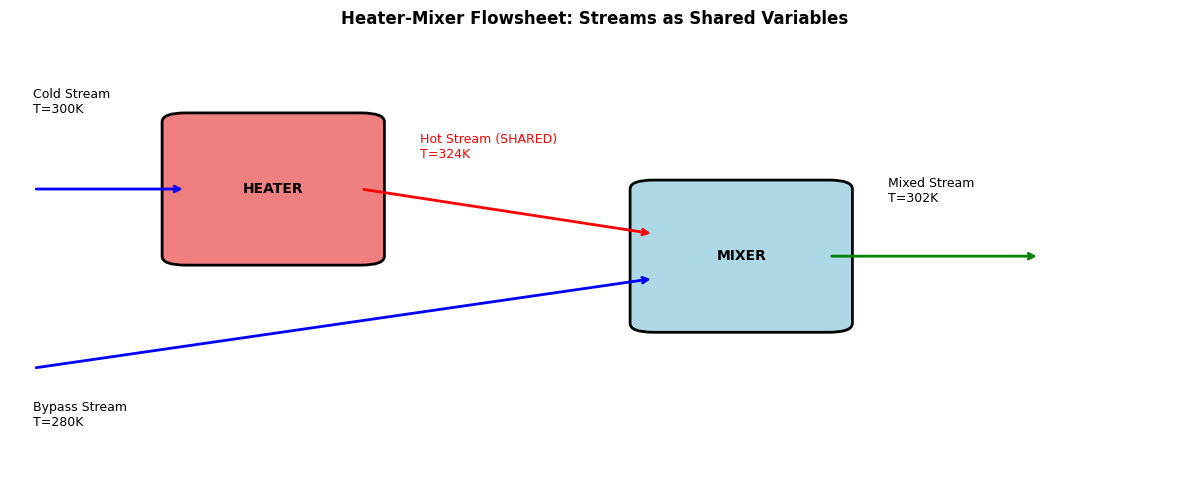

In [6]:
# Visualize the flowsheet with all stream data
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_heater_mixer_flowsheet(cold, hot, bypass, mixed, Q):
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Heater box: x=0.15-0.30, y=0.50-0.80
    heater_box = patches.FancyBboxPatch(
        (0.15, 0.50), 0.15, 0.30,
        boxstyle="round,pad=0.02",
        facecolor='lightcoral', edgecolor='black', linewidth=2
    )
    ax.add_patch(heater_box)
    ax.text(0.225, 0.65, 'HEATER', ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Mixer box: x=0.55-0.70, y=0.35-0.65
    mixer_box = patches.FancyBboxPatch(
        (0.55, 0.35), 0.15, 0.30,
        boxstyle="round,pad=0.02",
        facecolor='lightblue', edgecolor='black', linewidth=2
    )
    ax.add_patch(mixer_box)
    ax.text(0.625, 0.5, 'MIXER', ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Cold stream -> Heater (arrow ends at left edge of heater)
    ax.annotate('', xy=(0.15, 0.65), xytext=(0.02, 0.65),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    ax.text(0.02, 0.82, f'Cold Stream\nT={float(cold["T"]):.0f}K', fontsize=9)
    
    # Heater -> Mixer (arrow starts at right edge of heater, ends at left edge of mixer)
    ax.annotate('', xy=(0.55, 0.55), xytext=(0.30, 0.65),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
    ax.text(0.35, 0.72, f'Hot Stream (SHARED)\nT={float(hot["T"]):.0f}K', fontsize=9, color='red')
    
    # Bypass -> Mixer (arrow ends at left edge of mixer)
    ax.annotate('', xy=(0.55, 0.45), xytext=(0.02, 0.25),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    ax.text(0.02, 0.12, f'Bypass Stream\nT={float(bypass["T"]):.0f}K', fontsize=9)
    
    # Mixer -> Product (arrow starts at right edge of mixer)
    ax.annotate('', xy=(0.88, 0.5), xytext=(0.70, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='green'))
    ax.text(0.75, 0.62, f'Mixed Stream\nT={float(mixed["T"]):.0f}K', fontsize=9)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Heater-Mixer Flowsheet: Streams as Shared Variables', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

fig = draw_heater_mixer_flowsheet(cold_stream, hot_stream, bypass_stream, mixed_stream, 20000.0)


## Degrees of Freedom for Connected Systems

When we connect units, the degrees of freedom analysis becomes:

$$\text{DOF}_{system} = \text{DOF}_{unit1} + \text{DOF}_{unit2} - \text{shared variables}$$

The shared variables are counted ONCE, not twice.

For our heater-mixer system:
- Heater: 8 variables (2 streams × 4) - 4 equations = 4 DOF
- Mixer: 12 variables (3 streams × 4) - 4 equations = 8 DOF
- Shared stream (hot): 4 variables

Combined: (8 + 12 - 4) variables - (4 + 4) equations = 16 - 8 = **8 DOF**

We specify: cold stream (4), bypass stream (4), and heat duty (1) = 9 specifications.
Wait, that's 9, not 8! The extra one comes from the heater being over-specified if we give both Q and T_out.

In [7]:
# Let's verify by counting carefully

print("Degrees of Freedom Analysis - Connected System")
print("=" * 50)

# Variables
print("\nVARIABLES:")
print("  Cold stream: F_A, F_B, T, P  → 4")
print("  Hot stream:  F_A, F_B, T, P  → 4 (shared between heater and mixer)")
print("  Bypass stream: F_A, F_B, T, P → 4")
print("  Mixed stream: F_A, F_B, T, P → 4")
print("  Heat duty Q: 1")
print("  -------------------")
print("  Total: 17 variables")

# Equations
print("\nEQUATIONS:")
print("  Heater mass balance (A): F_hot_A = F_cold_A  → 1")
print("  Heater mass balance (B): F_hot_B = F_cold_B  → 1")
print("  Heater energy balance: Q = F*Cp*(T_hot - T_cold)  → 1")
print("  Heater pressure: P_hot = P_cold  → 1")
print("  Mixer mass balance (A): F_mix_A = F_hot_A + F_bypass_A  → 1")
print("  Mixer mass balance (B): F_mix_B = F_hot_B + F_bypass_B  → 1")
print("  Mixer energy balance: F_mix*T_mix = F_hot*T_hot + F_bypass*T_bypass  → 1")
print("  Mixer pressure: P_mix = min(P_hot, P_bypass)  → 1")
print("  -------------------")
print("  Total: 8 equations")

print("\nDEGREES OF FREEDOM: 17 - 8 = 9")
print("\nTo solve, we specify:")
print("  Cold stream: F_A, F_B, T, P  → 4 specs")
print("  Bypass stream: F_A, F_B, T, P → 4 specs")
print("  Heat duty Q: 1 spec")
print("  -------------------")
print("  Total: 9 specifications ✓")

Degrees of Freedom Analysis - Connected System

VARIABLES:
  Cold stream: F_A, F_B, T, P  → 4
  Hot stream:  F_A, F_B, T, P  → 4 (shared between heater and mixer)
  Bypass stream: F_A, F_B, T, P → 4
  Mixed stream: F_A, F_B, T, P → 4
  Heat duty Q: 1
  -------------------
  Total: 17 variables

EQUATIONS:
  Heater mass balance (A): F_hot_A = F_cold_A  → 1
  Heater mass balance (B): F_hot_B = F_cold_B  → 1
  Heater energy balance: Q = F*Cp*(T_hot - T_cold)  → 1
  Heater pressure: P_hot = P_cold  → 1
  Mixer mass balance (A): F_mix_A = F_hot_A + F_bypass_A  → 1
  Mixer mass balance (B): F_mix_B = F_hot_B + F_bypass_B  → 1
  Mixer energy balance: F_mix*T_mix = F_hot*T_hot + F_bypass*T_bypass  → 1
  Mixer pressure: P_mix = min(P_hot, P_bypass)  → 1
  -------------------
  Total: 8 equations

DEGREES OF FREEDOM: 17 - 8 = 9

To solve, we specify:
  Cold stream: F_A, F_B, T, P  → 4 specs
  Bypass stream: F_A, F_B, T, P → 4 specs
  Heat duty Q: 1 spec
  -------------------
  Total: 9 specifica

## Why Degrees of Freedom Matter

Understanding degrees of freedom helps you:

1. **Know what to specify**: DOF = number of values you must provide
2. **Avoid over-specification**: If DOF < 0, your system is inconsistent
3. **Avoid under-specification**: If DOF > 0, you can't solve uniquely
4. **Design experiments**: Each measurement eliminates one DOF

In simulation software, you'll often see errors like:
- "System is over-specified" (too many constraints)
- "System has no solution" (conflicting constraints)
- "Multiple solutions exist" (under-specified)

## Try It Yourself!

### Exercise 1: Count Degrees of Freedom
A **splitter** divides one stream into two:
```
               ──► Stream 2
    Stream 1 ─┤
               ──► Stream 3
```

The split ratio $\alpha$ defines the fraction going to stream 2.

Equations:
- $F_{2,i} = \alpha \cdot F_{1,i}$
- $F_{3,i} = (1-\alpha) \cdot F_{1,i}$
- $T_2 = T_3 = T_1$
- $P_2 = P_3 = P_1$

Count the variables, equations, and DOF for a 2-species system.

In [8]:
# Your analysis here
n_species = 2

# Variables:
# Stream 1: ?
# Stream 2: ?
# Stream 3: ?
# Split ratio alpha: ?
# Total: ?

# Equations:
# Mass balances stream 2: ?
# Mass balances stream 3: ?
# Temperature: ?
# Pressure: ?
# Total: ?

# DOF = ?

print("Your analysis:")
print(f"  Total variables: ?")
print(f"  Total equations: ?")
print(f"  DOF: ?")

Your analysis:
  Total variables: ?
  Total equations: ?
  DOF: ?


### Exercise 2: Implement a Splitter

In [9]:
def splitter_equations(inlet, alpha):
    """
    Split a stream into two based on split fraction alpha.
    
    Args:
        inlet: Input stream
        alpha: Fraction going to stream 2 (0 to 1)
    
    Returns:
        stream2, stream3: The two outlet streams
    """
    # Your code here
    # Hint: Use get_flows() and make_stream()
    pass

# Test it
# inlet = make_stream({'A': 100.0, 'B': 50.0}, T=350.0, P=200000.0)
# stream2, stream3 = splitter_equations(inlet, alpha=0.7)
# print(f"Stream 2: F_A = {get_flows(stream2)['A']} mol/s (should be 70)")
# print(f"Stream 3: F_A = {get_flows(stream3)['A']} mol/s (should be 30)")

### Exercise 3: Connect Units

Create a flowsheet with:
1. A feed stream
2. A splitter (70% to path A, 30% to path B)
3. A heater on path A (adds 10 kW)
4. A mixer that recombines both paths

Draw the flowsheet on paper first, then implement it.

In [10]:
# Your implementation here

## End-of-Tutorial Problems

### Problem 1: Reactor Equations

A reactor performs the reaction A → B with conversion $X$.

Write the mass balance equations for this reactor in terms of:
- Inlet flows: $F_{A,in}$, $F_{B,in}$
- Conversion: $X$
- Outlet flows: $F_{A,out}$, $F_{B,out}$

How many degrees of freedom does this reactor have?

*Your answer here:*



### Problem 2: Flash Drum

A flash drum separates a liquid feed into vapor and liquid products. The separation is governed by K-values:

$$K_i = \frac{y_i}{x_i}$$

where $y_i$ is vapor mole fraction and $x_i$ is liquid mole fraction.

List all the equations that govern a flash drum (mass balances, equilibrium relations, summation equations). How many equations are there for a 3-component system?

*Your answer here:*



---

## Key Takeaways

1. **Flowsheets are systems of equations** - Each unit contributes equations
2. **Streams are shared variables** - They connect units mathematically
3. **Degrees of freedom = Variables - Equations** - This tells you what to specify
4. **Simulation = Solving equations** - The computer finds values that satisfy all equations

---

## Next Steps

In the next notebook (**[00c: What is a Flowsheet? Advanced](./00c_what_is_a_flowsheet_advanced.ipynb)**), we'll explore:
- Computational graphs and information flow
- Sequential modular vs. equation-oriented approaches
- Why recycles complicate everything